In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


<b>1. Download and load the Student Performance dataset.</b>

In [69]:
df = pd.read_csv('student-por.csv', sep=';')
print("Shape:", df.shape)
df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

<b>2. Perform data preprocessing, including handling missing values (if any), encoding categorical variables, and feature scaling.</b>

In [71]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
df.isnull().sum()[df.isnull().sum() > 0]

Missing values per column:
0 total missing values


Series([], dtype: int64)

Inference: The dataset has no missing values, so no imputation is required.

In [72]:
binary_maps = {
    'school': {'GP': 0, 'MS': 1},
    'sex': {'F': 0, 'M': 1},
    'address': {'U': 0, 'R': 1},
    'famsize': {'LE3': 0, 'GT3': 1},
    'Pstatus': {'A': 0, 'T': 1},
    'schoolsup': {'no': 0, 'yes': 1},
    'famsup': {'no': 0, 'yes': 1},
    'paid': {'no': 0, 'yes': 1},
    'activities': {'no': 0, 'yes': 1},
    'nursery': {'no': 0, 'yes': 1},
    'higher': {'no': 0, 'yes': 1},
    'internet': {'no': 0, 'yes': 1},
    'romantic': {'no': 0, 'yes': 1},
}

df_enc = df.copy()
for col, mapping in binary_maps.items():
    df_enc[col] = df_enc[col].map(mapping)

nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)

bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print("Encoded shape:", df_enc.shape)
df_enc.head()

Encoded shape: (649, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,0,1,0,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,0,1,1,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,0,0,1,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0
3,0,0,15,0,1,1,4,2,1,3,...,0,0,0,1,0,1,0,0,1,0
4,0,0,16,0,1,1,3,3,1,2,...,0,0,1,0,0,1,0,0,0,0


Inference:
Binary yes/no columns (`schoolsup`, `famsup`, `paid`, `activities`, `nursery`, `higher`, `internet`, `romantic`) and binary categorical columns (`school`, `sex`, `address`, `famsize`, `Pstatus`) are label-encoded to 0/1.<br>
Multi-category nominal columns (`Mjob`, `Fjob`, `reason`, `guardian`) are one-hot encoded.

<b>3. Select appropriate input features and the target variable.</b>

In [73]:
target_col = 'G3'
X = df_enc.drop(columns=[target_col]).values.astype(float)
y = df_enc[target_col].values.astype(float)
feature_names = df_enc.drop(columns=[target_col]).columns.tolist()

print("Number of features:", X.shape[1])
print("Feature names:", feature_names)

Number of features: 41
Feature names: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


Inference: 
Target: `G3` as the final grade (0–20).<br>
Features: all remaining columns after encoding (demographics, school-related attributes, social factors, and the first-period and second-period grades `G1`, `G2`).


<b>4. Split the dataset into training and testing sets.</b>

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (519, 41) Test shape: (130, 41)


<b>Feature Scaling</b>

In [75]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0

X_train_scaled = (X_train - mu) / sigma
X_test_scaled = (X_test - mu) / sigma

print("Train mean (should be ~0):", np.round(X_train_scaled.mean(axis=0)[:5], 3))
print("Train std  (should be ~1):", np.round(X_train_scaled.std(axis=0)[:5], 3))

Train mean (should be ~0): [ 0.  0. -0.  0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1.]


Inference: Gradient Descent converges much faster (and more reliably) when features are on comparable scales. We standardize features (zero mean, unit variance) using statistics computed only from the training set, then apply the same transform to the test set to avoid data leakage.

<b>5. Implement Linear Regression using the Gradient Descent algorithm.</b>

In [76]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_pred = X.dot(w) + b
    cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    return cost


def gradient_descent(X, y, w, b, learning_rate, n_iterations):
    m = X.shape[0]
    cost_history = np.zeros(n_iterations)

    for i in range(n_iterations):
        y_pred = X.dot(w) + b
        error = y_pred - y

        dw = (1 / m) * X.T.dot(error)
        db = (1 / m) * np.sum(error)

        w -= learning_rate * dw
        b -= learning_rate * db

        cost_history[i] = compute_cost(X, y, w, b)

    return w, b, cost_history


<b>6. Experiment with different learning rates and observe their effect on model convergence.</b>

In [77]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
n_iterations = 1000
n_features = X_train_scaled.shape[1]

lr_results = {}

for lr in learning_rates:
    w_init = np.zeros(n_features)
    b_init = 0.0
    w, b, cost_history = gradient_descent(X_train_scaled, y_train, w_init, b_init, lr, n_iterations)
    lr_results[lr] = {'w': w, 'b': b, 'cost_history': cost_history}
    print(f"learning_rate={lr:<6} final_cost={cost_history[-1]:.4f}")

learning_rate=0.001  final_cost=10.4588


learning_rate=0.01   final_cost=0.7551
learning_rate=0.05   final_cost=0.7456
learning_rate=0.1    final_cost=0.7456
learning_rate=0.5    final_cost=770470986015490805598093097649058496013343545101115883257856.0000


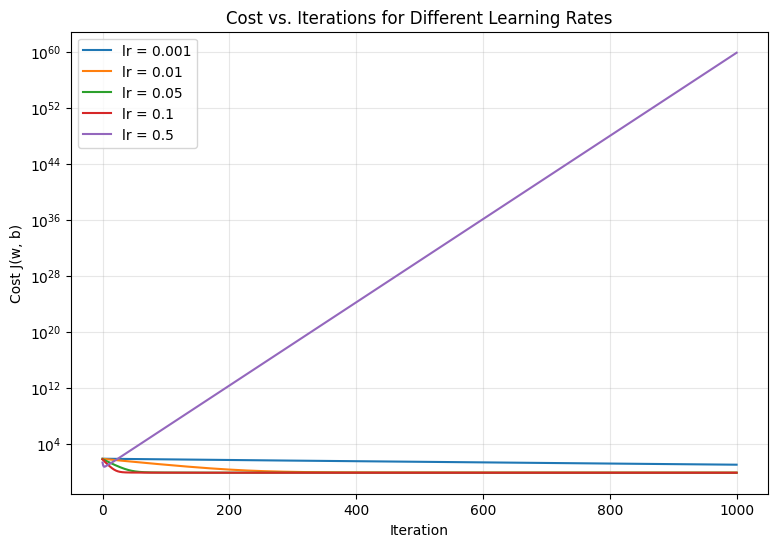

In [78]:
plt.figure(figsize=(9, 6))
for lr in learning_rates:
    ch = lr_results[lr]['cost_history']
    ch_clipped = np.clip(ch, None, np.nanpercentile(ch[np.isfinite(ch)], 100) if np.any(np.isfinite(ch)) else 1e6)
    plt.plot(ch_clipped, label=f'lr = {lr}')

plt.xlabel('Iteration')
plt.ylabel('Cost J(w, b)')
plt.title('Cost vs. Iterations for Different Learning Rates')
plt.legend()
plt.yscale('log')
plt.grid(alpha=0.3)
plt.show()

Inference: very small learning rates (e.g. 0.001) converge slowly and have not reached the minimum within 1000 iterations. Moderate learning rates (0.01 to 0.1) converge smoothly and quickly. Learning rates that are too large (e.g. 0.5, depending on the feature scaling) can cause oscillation or divergence of the cost function as gradient descent needs to take more number of steps to reach minimum. 

<b>7. Plot the loss (cost) versus the number of iterations.</b>

Selected best learning rate: 0.1


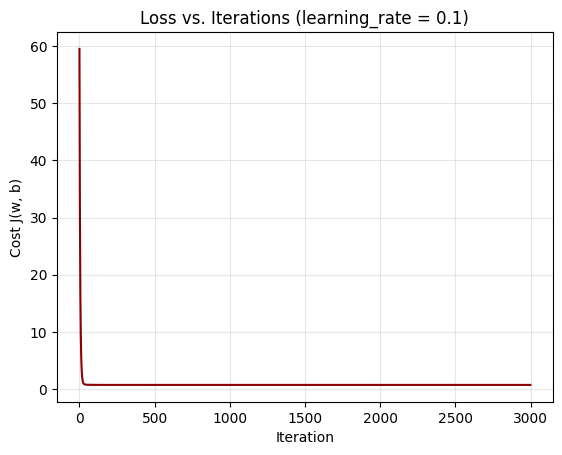

Final training cost: 0.7456


In [79]:
best_lr = min(learning_rates, key=lambda lr: lr_results[lr]['cost_history'][-1])
print("Selected best learning rate:", best_lr)

n_iterations_final = 3000
w_final = np.zeros(n_features)
b_final = 0.0
w_final, b_final, final_cost_history = gradient_descent(
    X_train_scaled, y_train, w_final, b_final, best_lr, n_iterations_final
)

plt.figure()
plt.plot(final_cost_history, color='darkred')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w, b)')
plt.title(f'Loss vs. Iterations (learning_rate = {best_lr})')
plt.grid(alpha=0.3)
plt.show()

print(f"Final training cost: {final_cost_history[-1]:.4f}")

The best-performing learning rate is selected from the experiment above and retrain with more iterations to ensure full convergence, plotting the loss curve.

<b>8. Evaluate the trained model using:<br>
Mean Absolute Error (MAE)<br>
Mean Squared Error (MSE)<br>
Root Mean Squared Error (RMSE)<br>
R2 Score
</b>

In [80]:
y_pred_test = X_test_scaled.dot(w_final) + b_final

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE):  {mae:.4f}")
print(f"Mean Squared Error (MSE):   {mse:.4f}")
print(f"Root Mean Squared Error:    {rmse:.4f}")
print(f"R2 Score:                   {r2:.4f}")

Mean Absolute Error (MAE):  0.7651
Mean Squared Error (MSE):   1.4759
Root Mean Squared Error:    1.2149
R2 Score:                   0.8487


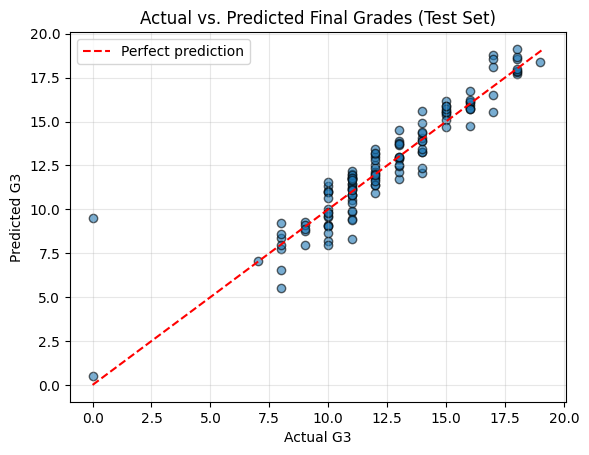

In [81]:
plt.figure()
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolor='k')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')
plt.title('Actual vs. Predicted Final Grades (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [82]:
coef_df = pd.DataFrame({'feature': feature_names, 'weight': w_final})
coef_df['abs_weight'] = coef_df['weight'].abs()
coef_df = coef_df.sort_values('abs_weight', ascending=False).drop(columns='abs_weight')
coef_df.head(10)

,feature,weight
27,G2,2.471735
26,G1,0.460262
34,Fjob_services,-0.240538
6,Medu,-0.166254
33,Fjob_other,-0.163351
0,school,-0.145509
37,reason_other,-0.128880
10,failures,-0.124303
20,freetime,-0.113908
35,Fjob_teacher,-0.107944


Feature Influence (Standardized Coefficients)<br>
Because all features were standardized before training, the magnitude of each weight reflects its relative influence on the prediction.

<b>Interpret the results and comment on the convergence behavior and prediction performance of the model.</b>

## 9. Interpretation of Results

**Convergence behavior:**
- Learning rates that were too small led to slow convergence — the cost decreased steadily but had not yet reached its minimum within a limited number of iterations.
- Moderate learning rates converged quickly and smoothly toward a stable minimum cost, thanks to feature standardization, which keeps gradients well-scaled across all features.
- Excessively large learning rates risked overshooting the minimum, producing oscillations or even divergence of the cost.
- The final model was trained with the empirically best learning rate for a larger number of iterations, and the loss curve flattens out, indicating convergence.

**Prediction performance:**
- The **R2 score** indicates the proportion of variance in the final grade (`G3`) explained by the model a value close to 1 indicates strong predictive power, largely because the first- and second-period grades (`G1`, `G2`) are highly correlated with the final grade.
- **MAE** gives the average absolute error in grade points, while **RMSE** penalizes larger errors more heavily; comparing the two indicates whether large outlier errors are present (RMSE noticeably higher than MAE suggests some larger misses).
- The scatter plot of actual vs. predicted grades shows points clustering closely around the diagonal (perfect-prediction) line, confirming that the linear model captures the dominant relationship between the features and the target.

Overall Inference: Gradient Descent successfully found a good approximation of the closed-form (normal equation) linear regression solution, and the choice of learning rate is critical too small wastes iterations, too large risks instability, while feature scaling greatly widens the range of workable learning rates.

<b>Extra to understand how learning rate is changing on each iter for different learning rates</b>

In [83]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_pred = X.dot(w) + b
    cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
    return cost


def gradient_descent(X, y, w, b, learning_rate, n_iterations, verbose=False, print_every=100):
    m = X.shape[0]
    cost_history = np.zeros(n_iterations)

    for i in range(n_iterations):
        y_pred = X.dot(w) + b
        error = y_pred - y

        dw = (1 / m) * X.T.dot(error)
        db = (1 / m) * np.sum(error)

        w -= learning_rate * dw
        b -= learning_rate * db

        cost_history[i] = compute_cost(X, y, w, b)

        if verbose and (i % print_every == 0 or i == n_iterations - 1):
            print(f"iter {i:>5}  cost = {cost_history[i]:.6f}")

        # Flag the moment the cost starts blowing up
        if i > 0 and cost_history[i] > cost_history[i - 1] * 10:
            print(f"⚠️  Diverging at iteration {i}: cost jumped from "
                  f"{cost_history[i-1]:.4f} to {cost_history[i]:.4e} "
                  f"(learning_rate={learning_rate} is too large)")

    return w, b, cost_history

In [84]:
w_init = np.zeros(n_features)
b_init = 0.0
w, b, cost_history = gradient_descent(
    X_train_scaled, y_train, w_init, b_init,
    learning_rate=0.01, n_iterations=1000,
    verbose=True, print_every=1
)

iter     0  cost = 73.173694
iter     1  cost = 71.582508
iter     2  cost = 70.034749
iter     3  cost = 68.528627
iter     4  cost = 67.062460
iter     5  cost = 65.634671
iter     6  cost = 64.243775
iter     7  cost = 62.888373
iter     8  cost = 61.567147
iter     9  cost = 60.278855
iter    10  cost = 59.022323
iter    11  cost = 57.796442
iter    12  cost = 56.600162
iter    13  cost = 55.432491
iter    14  cost = 54.292485
iter    15  cost = 53.179252
iter    16  cost = 52.091942
iter    17  cost = 51.029749
iter    18  cost = 49.991904
iter    19  cost = 48.977676
iter    20  cost = 47.986366
iter    21  cost = 47.017310
iter    22  cost = 46.069870
iter    23  cost = 45.143438
iter    24  cost = 44.237432
iter    25  cost = 43.351294
iter    26  cost = 42.484489
iter    27  cost = 41.636503
iter    28  cost = 40.806843
iter    29  cost = 39.995034
iter    30  cost = 39.200621
iter    31  cost = 38.423164
iter    32  cost = 37.662239
iter    33  cost = 36.917438
iter    34  co